# 感染者数外生変数モデル：中間発表用実験ノート

感染者数をCOVID期内の月次強弱を表す外部時系列として導入し、既存の状態空間モデルで補助的に推定する。係数を時変にするのではなく、感染者数系列そのものを時変する固定係数の外生変数として扱う。

本ノートは実験結果の再現・診断用であり、paper_jsce、既存のoutput/sensitivityおよびoutput/forecastsは変更しない。


## 1. 定式化

既存の観測方程式は、対数宅配便取扱個数 y_t をトレンド μ_t、季節成分 γ_t、イベントダミー d_t および観測誤差で表す。

$$y_t = μ_t + γ_t + β^T d_t + ε_t.$$

感染者数外生変数モデルでは、前処理済みの log1p_cases_lag0 または log1p_cases_lag1 を x_t として追加する。

$$y_t = μ_t + γ_t + β^T d_t + θ x_t + ε_t.$$

ここで θ は全期間で一定の係数であり、x_t の値が月ごとに変化する。これは係数をランダムウォーク化した時変係数モデルではない。


### 状態方程式とラグの定義

すべての仕様で既存モデルと同じ12か月季節状態を用いる。局所線形トレンドは

$$μ_{t+1}=μ_t+δ_t+η_{μ,t}, \qquad δ_{t+1}=δ_t+η_{δ,t},$$

であり、季節状態はダミー変数型の和ゼロ制約を持つ。x_t はCOVID対象期間（2020年3月～2023年5月）に限って log(1+C_t) を取り、期間外は0とした。

- lag0：x_t = log1p_cases_lag0（同月の月次感染者数）
- lag1：x_t = log1p_cases_lag1（1か月前の月次感染者数）

2023年5月8日の日次レコードは前処理で2023年5月の月次合計に含めている。公式最終集計日との対応は別途確認事項として残す。


In [1]:
from pathlib import Path
import importlib.util
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from IPython.display import display
from statsmodels.stats.diagnostic import acorr_ljungbox

# プロジェクトルートを実行場所から探索する。
candidates = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
for candidate in candidates:
    if (candidate / "data/processed/parcel_volume_connected.csv").exists():
        PROJECT_ROOT = candidate.resolve()
        break
else:
    raise FileNotFoundError("プロジェクトルートを確認できない")

SCRIPT_PATH = PROJECT_ROOT / "scripts/experimental/run_covid_cases_exog.py"
spec = importlib.util.spec_from_file_location("covid_cases_exog_impl", SCRIPT_PATH)
impl = importlib.util.module_from_spec(spec)
assert spec.loader is not None
spec.loader.exec_module(impl)

MONTHLY_PATH = PROJECT_ROOT / "data/experimental/covid_cases/processed/monthly_cases.csv"
PARCEL_PATH = PROJECT_ROOT / "data/processed/parcel_volume_connected.csv"
METRICS_DIR = PROJECT_ROOT / "output/covid_cases_exog/metrics"
FIGURES_DIR = PROJECT_ROOT / "output/covid_cases_exog/figures"
RESULT_NOTE = PROJECT_ROOT / "docs/interim_presentation/covid_cases_exog_result_note.md"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("monthly input:", MONTHLY_PATH)
print("parcel input:", PARCEL_PATH)
print("result note:", RESULT_NOTE)


monthly input: C:\Users\fugat\Desktop\python_project\Transport_amount_project\data\experimental\covid_cases\processed\monthly_cases.csv
parcel input: C:\Users\fugat\Desktop\python_project\Transport_amount_project\data\processed\parcel_volume_connected.csv
result note: C:\Users\fugat\Desktop\python_project\Transport_amount_project\docs\interim_presentation\covid_cases_exog_result_note.md


In [2]:
# monthly_cases.csvを読み込み、宅配便系列へ結合する。
monthly_input = pd.read_csv(MONTHLY_PATH, encoding="utf-8-sig")
parcel_df, metadata = impl.build_analysis_data()

# x_tを明示的な列名でも保持し、lag0/lag1の値を確認する。
parcel_df["x_t_lag0"] = parcel_df["log1p_cases_lag0"]
parcel_df["x_t_lag1"] = parcel_df["log1p_cases_lag1"]
selected = parcel_df.loc[:, ["y", "monthly_cases_all", "covid_period", "x_t_lag0", "x_t_lag1", "post_stat_change"]]

display(monthly_input.head(3))
display(selected.loc[selected["monthly_cases_all"].gt(0)].head(5))
print("結合後の観測数:", len(parcel_df), "か月")
print("宅配便期間:", parcel_df.index.min().strftime("%Y-%m"), "--", parcel_df.index.max().strftime("%Y-%m"))
print("COVID対象月数:", int(parcel_df["covid_period"].sum()))
outside_nonzero = ((~parcel_df["covid_period"]) & ((parcel_df["x_t_lag0"] != 0) | (parcel_df["x_t_lag1"] != 0))).sum()
print("対象期間外でx_t_lag0またはx_t_lag1が非ゼロの日数:", int(outside_nonzero))
print("2023年5月:", parcel_df.loc[parcel_df.index.strftime("%Y-%m") == "2023-05", ["monthly_cases_all", "x_t_lag0", "x_t_lag1"]].to_dict("records"))


,month,monthly_cases_all,monthly_prefecture_total,all_minus_prefecture_total,daily_rows,last_daily_date,covid_period,cases_exog,log1p_cases,log1p_cases_lag0,log1p_cases_lag1
0,2020-01,14,14,0,16,2020-01-31,False,0,0.000000,0.000000,0.0
1,2020-02,213,213,0,29,2020-02-29,False,0,0.000000,0.000000,0.0
2,2020-03,1936,1936,0,31,2020-03-31,True,1936,7.568896,7.568896,0.0


,y,monthly_cases_all,covid_period,x_t_lag0,x_t_lag1,post_stat_change
label,,,,,,
2020-03-01,12.815906,1936.0,True,7.568896,0.000000,0
2020-04-01,12.840547,11952.0,True,9.388738,7.568896,0
2020-05-01,12.851399,2439.0,True,7.799753,9.388738,0
2020-06-01,12.898537,1741.0,True,7.462789,7.799753,0
2020-07-01,12.972779,17379.0,True,9.763075,7.462789,0


結合後の観測数: 287 か月
宅配便期間: 2002-04 -- 2026-02
COVID対象月数: 39
対象期間外でx_t_lag0またはx_t_lag1が非ゼロの日数: 0
2023年5月: [{'monthly_cases_all': 81654.0, 'x_t_lag0': 11.310258333510845, 'x_t_lag1': 12.486405276880786}]


## 2. 推定仕様

既存の5変数モデルを比較基準とし、感染者数変数を加えたlag1・lag0仕様、およびCOVID期ダミーを除いた補助仕様を推定する。実装は既存の run_covid_cases_exog.py が利用する状態空間モデルと同一である。


In [3]:
SPECS = impl.SPECIFICATIONS
fit_rows = []
fit_coefficients = []
fit_objects = {}

def fit_with_components(df, model_id, label, exog_names):
    exog = df[exog_names].astype(float)
    names_full = impl.param_names(exog_names)
    model = impl.LocalLinearTrendSeasonalWithMultiFixedExog(
        endog=df["y"],
        exog_list=[exog[name] for name in exog_names],
        param_names=names_full,
        seasonal_period=12,
    )
    result = model.fit(
        start_params=impl.start_params(exog_names),
        maxiter=1000,
        disp=False,
    )
    params = np.asarray(result.params, dtype=float)
    bse = np.asarray(result.bse, dtype=float)
    pvalues = np.asarray(result.pvalues, dtype=float)
    names = dict(zip(names_full, params))
    smoothed = np.asarray(result.smoother_results.smoothed_state, dtype=float)
    trend, seasonal = smoothed[0], smoothed[2]
    event_effects = {}
    total_event = np.zeros(len(df))
    for name in exog_names:
        parameter = impl.PARAM_NAME_OVERRIDES.get(name, name + "_effect")
        event_effects[name] = names[parameter] * exog[name].to_numpy()
        total_event += event_effects[name]
    fitted = trend + seasonal + total_event
    residual = df["y"].to_numpy() - fitted
    lb = acorr_ljungbox(residual, lags=[12, 24], return_df=True)
    retvals = getattr(result, "mle_retvals", {}) or {}
    row = {
        "model_id": model_id,
        "model_label": label,
        "converged": retvals.get("converged"),
        "warnflag": retvals.get("warnflag"),
        "log_likelihood": float(result.llf),
        "aic": float(result.aic),
        "bic": float(result.bic),
        "residual_std": float(np.std(residual, ddof=1)),
        "residual_rmse": float(np.sqrt(np.mean(residual ** 2))),
        "ljung_box_p_value_lag12": float(lb["lb_pvalue"].iloc[0]),
        "ljung_box_p_value_lag24": float(lb["lb_pvalue"].iloc[1]),
    }
    for i, parameter in enumerate(names_full):
        is_event = parameter.endswith("_effect") or parameter == "hike_effect"
        fit_coefficients.append({
            "model_id": model_id,
            "model_label": label,
            "parameter": parameter,
            "estimate": params[i],
            "std_error": bse[i],
            "p_value": pvalues[i],
            "percent_conversion": impl.effect_percent(params[i]) if is_event else np.nan,
        })
    return row, {
        "observed": df["y"].to_numpy(),
        "fitted": fitted,
        "trend": trend,
        "seasonal": seasonal,
        "residual": residual,
        "event_effects": event_effects,
        "result": result,
    }

for model_id, label, exog_names in SPECS:
    row, components = fit_with_components(parcel_df, model_id, label, exog_names)
    fit_rows.append(row)
    fit_objects[model_id] = components

fit_comparison = pd.DataFrame(fit_rows)
display(fit_comparison[[
    "model_id", "converged", "warnflag", "aic", "bic",
    "residual_std", "residual_rmse",
    "ljung_box_p_value_lag12", "ljung_box_p_value_lag24"
]])


C:\Users\fugat\Desktop\python_project\Transport_amount_project\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


C:\Users\fugat\Desktop\python_project\Transport_amount_project\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


C:\Users\fugat\Desktop\python_project\Transport_amount_project\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


C:\Users\fugat\Desktop\python_project\Transport_amount_project\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


,model_id,converged,warnflag,aic,bic,residual_std,residual_rmse,ljung_box_p_value_lag12,ljung_box_p_value_lag24
0,current_five_event,True,0,-1124.138874,-1043.630265,0.010720,0.010701,2.192728e-07,0.000011
1,covid_main_log1p_lag1,True,0,-1114.718707,-1041.529063,0.010821,0.010802,7.151563e-07,0.000020
2,covid_main_log1p_lag0,True,0,-1114.082130,-1040.892486,0.010949,0.010930,6.476006e-07,0.000018
3,log1p_lag1_only,True,0,-1114.584718,-1045.054556,0.010424,0.010406,8.714549e-07,0.000018


In [4]:
# 既存CSVとの主要指標一致を確認する（CSV自体は上書きしない）。
stored_comparison = pd.read_csv(METRICS_DIR / "model_comparison.csv")
stored_coefficients = pd.read_csv(METRICS_DIR / "coefficients.csv")
stored_design = pd.read_csv(METRICS_DIR / "design_diagnostics.csv")
key_metrics = ["log_likelihood", "aic", "bic", "residual_std", "residual_rmse"]
check = fit_comparison.merge(
    stored_comparison[["model_id", *key_metrics]],
    on="model_id",
    suffixes=("_notebook", "_csv"),
)
for metric in key_metrics:
    check[metric + "_abs_diff"] = (
        check[metric + "_notebook"] - check[metric + "_csv"]
    ).abs()
display(check[["model_id"] + [metric + "_abs_diff" for metric in key_metrics]])
event_parameters = stored_coefficients[
    stored_coefficients["parameter"].str.endswith("_effect")
].copy()
event_parameters["variable"] = event_parameters["parameter"].replace({
    "covid_main_effect": "covid_main",
    "post_stat_change_effect": "post_stat_change",
    "log1p_cases_lag0_effect": "cases_exog_lag0",
    "log1p_cases_lag1_effect": "cases_exog_lag1",
})
display(event_parameters[[
    "model_id", "variable", "estimate", "std_error",
    "percent_conversion", "p_value"
]])
design_view = ["model_id", "design_condition_number"] + [
    column for column in stored_design.columns if column.startswith("corr_")
]
display(stored_design[design_view])
print("主要指標の再計算値と保存CSVの最大絶対差:",
      float(check[[metric + "_abs_diff" for metric in key_metrics]].to_numpy().max()))


,model_id,log_likelihood_abs_diff,aic_abs_diff,bic_abs_diff,residual_std_abs_diff,residual_rmse_abs_diff
0,current_five_event,0.0,0.0,0.0,3.469447e-17,9.887924e-17
1,covid_main_log1p_lag1,0.0,0.0,0.0,6.938894e-17,9.540979e-17
2,covid_main_log1p_lag0,0.0,0.0,0.0,7.459311e-17,4.683753e-17
3,log1p_lag1_only,0.0,0.0,0.0,5.030698e-17,0.000000e+00


,model_id,variable,estimate,std_error,percent_conversion,p_value
4,current_five_event,hike_effect,-0.023351,0.027214,-2.308095,0.390863
5,current_five_event,covid_main,0.030467,0.018648,3.093559,0.102304
6,current_five_event,covid_wave1_effect,0.051196,0.017872,5.252939,0.004176
7,current_five_event,covid_2021_effect,0.016180,0.012627,1.631127,0.200056
8,current_five_event,post_stat_change,-0.045299,0.024642,-4.428871,0.066020
13,covid_main_log1p_lag1,covid_main,0.031000,0.016562,3.148535,0.061247
14,covid_main_log1p_lag1,cases_exog_lag1,0.001393,0.001479,0.139390,0.346183
15,covid_main_log1p_lag1,post_stat_change,-0.044722,0.028130,-4.373636,0.111877
20,covid_main_log1p_lag0,covid_main,0.039246,0.027678,4.002642,0.156202
21,covid_main_log1p_lag0,cases_exog_lag0,0.000475,0.002640,0.047518,0.857179


,model_id,design_condition_number,corr_hike_dummy_covid_main,corr_hike_dummy_covid_wave1,corr_hike_dummy_covid_2021,corr_hike_dummy_post_stat_change,corr_covid_main_covid_wave1,corr_covid_main_covid_2021,corr_covid_main_post_stat_change,corr_covid_wave1_covid_2021,corr_covid_wave1_post_stat_change,corr_covid_2021_post_stat_change,corr_covid_main_log1p_cases_lag1,corr_log1p_cases_lag1_post_stat_change,corr_covid_main_log1p_cases_lag0,corr_log1p_cases_lag0_post_stat_change
0,current_five_event,5.333172,-0.127791,-0.026995,-0.057982,-0.13528,0.211245,0.453725,0.118428,-0.015073,-0.035167,-0.075533,NaN,NaN,NaN,NaN
1,covid_main_log1p_lag1,49.084282,NaN,NaN,NaN,NaN,NaN,NaN,0.118428,NaN,NaN,NaN,0.963894,0.177444,NaN,NaN
2,covid_main_log1p_lag0,64.805714,NaN,NaN,NaN,NaN,NaN,NaN,0.118428,NaN,NaN,NaN,NaN,NaN,0.978831,0.163014
3,log1p_lag1_only,11.914876,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.177444,NaN,NaN


主要指標の再計算値と保存CSVの最大絶対差: 9.8879238130678e-17


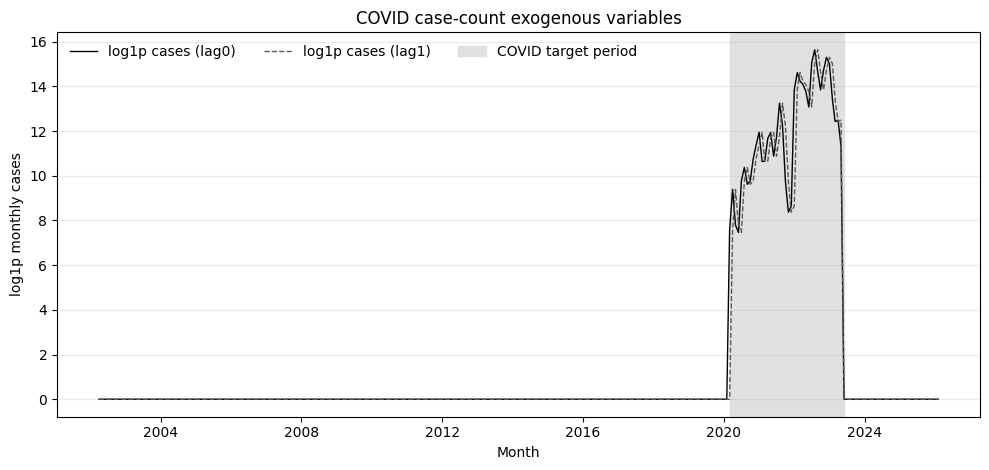

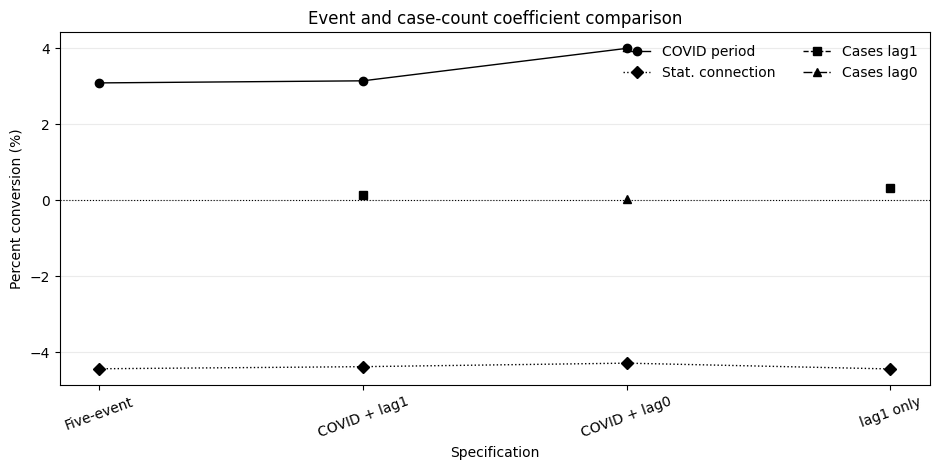

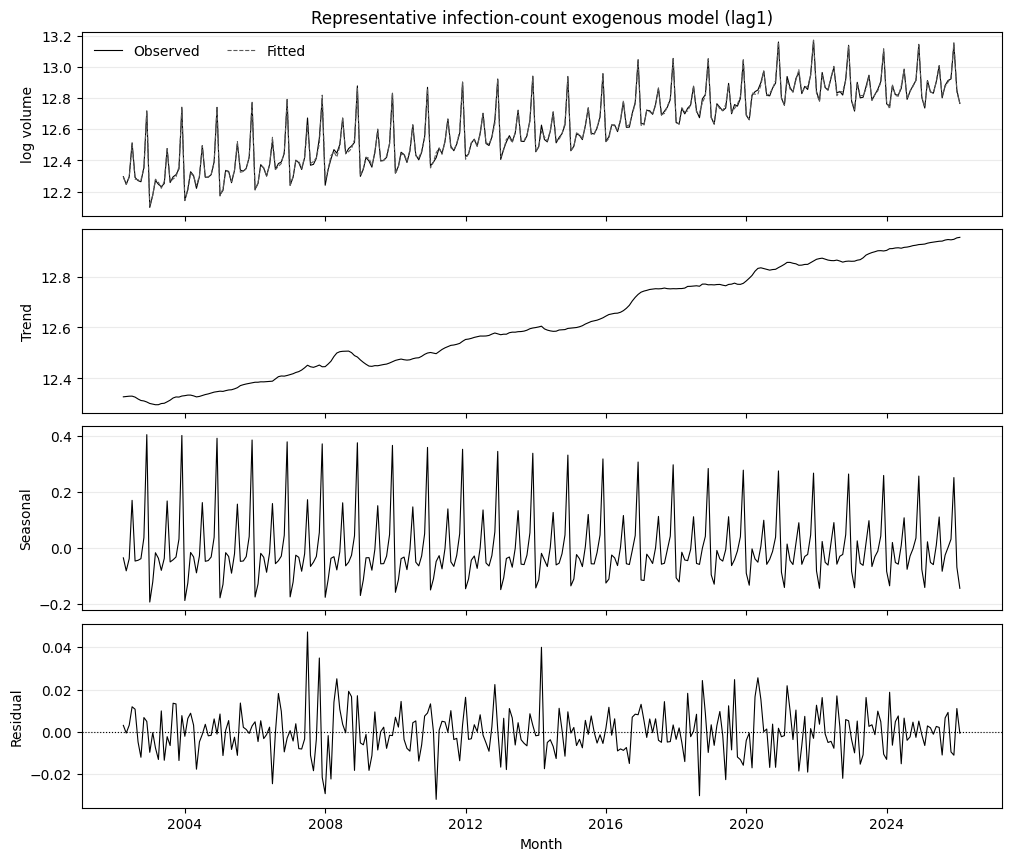

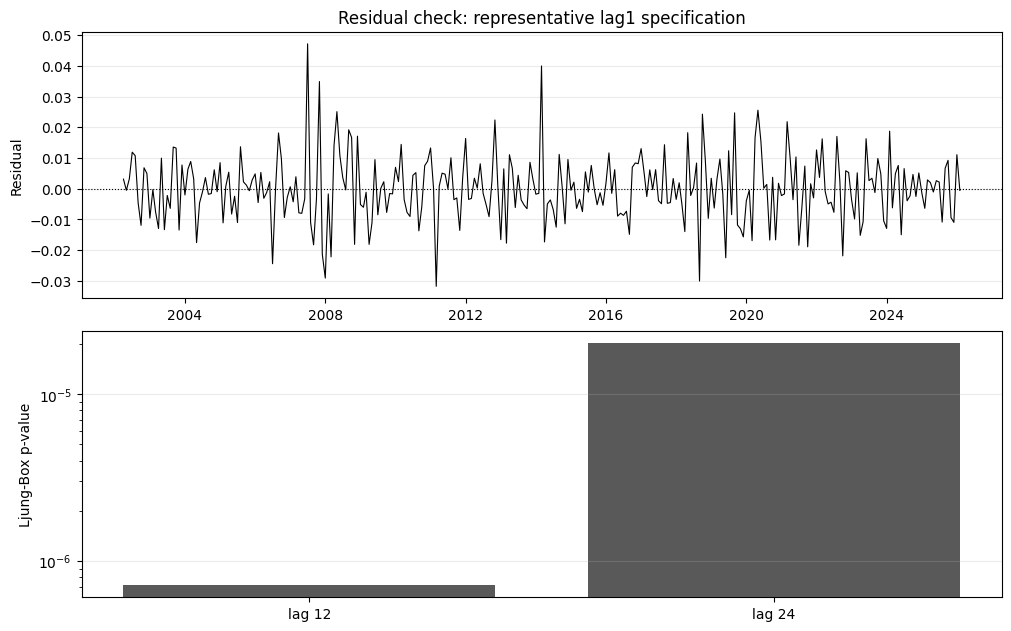

In [5]:
# 図1：感染者数外生変数系列
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot(parcel_df.index, parcel_df["x_t_lag0"], color="black", linewidth=1.0, label="log1p cases (lag0)")
ax.plot(parcel_df.index, parcel_df["x_t_lag1"], color="0.35", linewidth=1.0, linestyle="--", label="log1p cases (lag1)")
ax.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2023-05-31"), color="0.88", label="COVID target period")
ax.set_ylabel("log1p monthly cases")
ax.set_xlabel("Month")
ax.set_title("COVID case-count exogenous variables")
ax.legend(frameon=False, ncol=3)
ax.grid(True, axis="y", alpha=0.25)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "cases_exog_series.png", dpi=220, bbox_inches="tight")
plt.show()
plt.close(fig)

# 図2：感染者数係数比較
plot_params = [
    "covid_main_effect", "log1p_cases_lag1_effect",
    "log1p_cases_lag0_effect", "post_stat_change_effect",
]
labels = {
    "covid_main_effect": "COVID period",
    "log1p_cases_lag1_effect": "Cases lag1",
    "log1p_cases_lag0_effect": "Cases lag0",
    "post_stat_change_effect": "Stat. connection",
}
coef_plot = event_parameters[event_parameters["parameter"].isin(plot_params)].copy()
model_order = ["current_five_event", "covid_main_log1p_lag1", "covid_main_log1p_lag0", "log1p_lag1_only"]
model_labels = ["Five-event", "COVID + lag1", "COVID + lag0", "lag1 only"]
style_map = {
    "covid_main_effect": ("-", "o"),
    "log1p_cases_lag1_effect": ("--", "s"),
    "log1p_cases_lag0_effect": ("-.", "^"),
    "post_stat_change_effect": (":", "D"),
}
fig, ax = plt.subplots(figsize=(9.5, 4.8))
x = np.arange(len(model_order))
for parameter, group in coef_plot.groupby("parameter", sort=False):
    values = group.set_index("model_id").reindex(model_order)["percent_conversion"]
    linestyle, marker = style_map[parameter]
    ax.plot(x, values, color="black", linestyle=linestyle, marker=marker, linewidth=1.0, label=labels[parameter])
ax.axhline(0, color="black", linewidth=0.8, linestyle=":")
ax.set_ylabel("Percent conversion (%)")
ax.set_xlabel("Specification")
ax.set_title("Event and case-count coefficient comparison")
ax.set_xticks(x, model_labels)
ax.tick_params(axis="x", rotation=20)
ax.legend(frameon=False, ncol=2)
ax.grid(True, axis="y", alpha=0.25)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "cases_exog_coefficients.png", dpi=220, bbox_inches="tight")
plt.show()
plt.close(fig)

# 図3：代表仕様の成分分解
representative = fit_objects["covid_main_log1p_lag1"]
fig, axes = plt.subplots(4, 1, figsize=(10, 8.5), sharex=True, constrained_layout=True)
axes[0].plot(parcel_df.index, representative["observed"], color="black", linewidth=0.8, label="Observed")
axes[0].plot(parcel_df.index, representative["fitted"], color="0.35", linestyle="--", linewidth=0.8, label="Fitted")
axes[0].set_ylabel("log volume")
axes[0].set_title("Representative infection-count exogenous model (lag1)")
axes[0].legend(frameon=False, ncol=2)
axes[1].plot(parcel_df.index, representative["trend"], color="black", linewidth=0.8)
axes[1].set_ylabel("Trend")
axes[2].plot(parcel_df.index, representative["seasonal"], color="black", linewidth=0.8)
axes[2].set_ylabel("Seasonal")
axes[3].plot(parcel_df.index, representative["residual"], color="black", linewidth=0.8)
axes[3].axhline(0, color="black", linestyle=":", linewidth=0.8)
axes[3].set_ylabel("Residual")
axes[3].set_xlabel("Month")
for axis in axes:
    axis.grid(True, axis="y", alpha=0.25)
    axis.xaxis.set_major_locator(mdates.YearLocator(4))
    axis.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.savefig(FIGURES_DIR / "cases_exog_components_lag1.png", dpi=220, bbox_inches="tight")
plt.show()
plt.close(fig)

# 図4：代表仕様の残差確認
lb_rep = acorr_ljungbox(representative["residual"], lags=[12, 24], return_df=True)
fig, axes = plt.subplots(2, 1, figsize=(10, 6.2), constrained_layout=True)
axes[0].plot(parcel_df.index, representative["residual"], color="black", linewidth=0.8)
axes[0].axhline(0, color="black", linestyle=":", linewidth=0.8)
axes[0].set_ylabel("Residual")
axes[0].set_title("Residual check: representative lag1 specification")
axes[0].grid(True, axis="y", alpha=0.25)
axes[1].bar(["lag 12", "lag 24"], lb_rep["lb_pvalue"].to_numpy(), color="0.35")
axes[1].set_yscale("log")
axes[1].set_ylabel("Ljung-Box p-value")
axes[1].grid(True, axis="y", alpha=0.25)
fig.savefig(FIGURES_DIR / "cases_exog_residuals.png", dpi=220, bbox_inches="tight")
plt.show()
plt.close(fig)


## 3. 診断結果の読み方と注意点

- 4仕様の収束状況、対数尤度、AIC/BIC、残差標準偏差、RMSE、Ljung--Box p値は保存済みCSVと照合した。
- 設計行列の相関と条件数は design_diagnostics.csv から確認する。COVID期ダミーと感染者数系列の相関が高い場合、両者の寄与を標本内で明確に分離することは難しい。
- Ljung--Box p値が小さい場合も、感染者数外生変数の追加で残差自己相関が解消したとは解釈しない。
- 感染者数係数は指定期間・変換・ラグに対応するモデル上の水準差であり、感染者数の因果効果ではない。

## 4. 出力ファイル

- 既存結果：output/covid_cases_exog/metrics/model_comparison.csv、coefficients.csv、design_diagnostics.csv
- 本ノートで保存した図：cases_exog_series.png、cases_exog_coefficients.png、cases_exog_components_lag1.png、cases_exog_residuals.png
- 結果整理メモ：docs/interim_presentation/covid_cases_exog_result_note.md

本ノートでは、外部テストによる予測評価、ラグの事前選択、感染者数データの代替定義比較、完全な時変係数モデルの推定は行っていない。


## 5. COVID期内で中心化・標準化した感染者数変数

第一段階では、対象期間外を0とした素朴な log1p_cases_lag0 / lag1 を用いた。ここでは、COVID対象期間 C（2020年3月～2023年5月）内の月次感染者数 u_t = log(1 + monthly_cases_t) について平均 mean_C と母標準偏差 sd_C（ddof=0）を計算し、

x_t = covid_period_t (u_t - mean_C) / sd_C

を作成する。lag0は当月のu_t、lag1は前月のu_tを用いた後、観測時点 t がCOVID期外の場合に0とする。したがって、中心化・標準化は係数のスケールと切片的な役割分担を整理するためのものであり、感染者数係数を時変化させるものではない。


In [6]:
# 中心化・標準化した感染者数変数を作成する。
centered_case = monthly_input.copy()
centered_case["date"] = pd.to_datetime(centered_case["month"].astype(str) + "-01")
centered_case["monthly_cases_all"] = pd.to_numeric(centered_case["monthly_cases_all"], errors="raise")
centered_case["u_t"] = np.log1p(centered_case["monthly_cases_all"])
centered_case["covid_period_centered"] = centered_case["date"].between(
    pd.Timestamp("2020-03-01"), pd.Timestamp("2023-05-01")
)
u_covid = centered_case.loc[centered_case["covid_period_centered"], "u_t"]
mean_C = float(u_covid.mean())
sd_C = float(u_covid.std(ddof=0))
if not np.isfinite(sd_C) or sd_C <= 0:
    raise ValueError("COVID期間のu_t標準偏差が正でない")
centered_case["u_lag1"] = centered_case["u_t"].shift(1)
centered_case["centered_log1p_cases_lag0"] = np.where(
    centered_case["covid_period_centered"],
    (centered_case["u_t"] - mean_C) / sd_C,
    0.0,
)
centered_case["centered_log1p_cases_lag1"] = np.where(
    centered_case["covid_period_centered"],
    (centered_case["u_lag1"] - mean_C) / sd_C,
    0.0,
)

centered_map = centered_case.set_index("date")[
    ["centered_log1p_cases_lag0", "centered_log1p_cases_lag1"]
].reindex(parcel_df.index)
centered_df = parcel_df.copy()
for column in ["centered_log1p_cases_lag0", "centered_log1p_cases_lag1"]:
    centered_df[column] = centered_map[column].fillna(0.0)

print("mean_C:", mean_C)
print("sd_C (ddof=0):", sd_C)
print("COVID月数:", int(centered_case["covid_period_centered"].sum()))
display(centered_case.loc[centered_case["covid_period_centered"], [
    "month", "monthly_cases_all", "u_t",
    "centered_log1p_cases_lag0", "centered_log1p_cases_lag1"
]].head(5))
print("対象期間外で中心化変数が非ゼロの日数:",
      int(((~centered_df["covid_period"]) &
           ((centered_df["centered_log1p_cases_lag0"] != 0) |
            (centered_df["centered_log1p_cases_lag1"] != 0))).sum()))
print("2023年5月の中心化変数:",
      centered_df.loc[
          centered_df.index.strftime("%Y-%m") == "2023-05",
          ["centered_log1p_cases_lag0", "centered_log1p_cases_lag1"]
      ].to_dict("records"))


mean_C: 11.875645231137298
sd_C (ddof=0): 2.308280102799593
COVID月数: 39


,month,monthly_cases_all,u_t,centered_log1p_cases_lag0,centered_log1p_cases_lag1
2,2020-03,1936,7.568896,-1.865783,-2.820138
3,2020-04,11952,9.388738,-1.077386,-1.865783
4,2020-05,2439,7.799753,-1.765770,-1.077386
5,2020-06,1741,7.462789,-1.911751,-1.765770
6,2020-07,17379,9.763075,-0.915214,-1.911751


対象期間外で中心化変数が非ゼロの日数: 0
2023年5月の中心化変数: [{'centered_log1p_cases_lag0': -0.24493860036341633, 'centered_log1p_cases_lag1': 0.2645952911012528}]


In [7]:
# 中心化仕様4モデルを推定し、既存の素朴仕様と別名で保存する。
CENTERED_SPECS = [
    (
        "centered_current_five_event",
        "現行5変数モデル（中心化確認）",
        ["hike_dummy", "covid_main", "covid_wave1", "covid_2021", "post_stat_change"],
    ),
    (
        "centered_covid_main_log1p_lag1",
        "COVID期ダミー＋中心化感染者数ラグ1＋統計接続ダミー",
        ["covid_main", "centered_log1p_cases_lag1", "post_stat_change"],
    ),
    (
        "centered_covid_main_log1p_lag0",
        "COVID期ダミー＋中心化感染者数ラグ0＋統計接続ダミー",
        ["covid_main", "centered_log1p_cases_lag0", "post_stat_change"],
    ),
    (
        "centered_log1p_lag1_only",
        "中心化感染者数ラグ1＋統計接続ダミー",
        ["centered_log1p_cases_lag1", "post_stat_change"],
    ),
]

centered_fit_rows = []
centered_fit_coefficients = []
centered_fit_objects = {}
# 既存のfit_with_componentsはこのグローバル配列へ係数を追加する。
fit_coefficients = centered_fit_coefficients
fit_objects = centered_fit_objects

for model_id, label, exog_names in CENTERED_SPECS:
    row, components = fit_with_components(centered_df, model_id, label, exog_names)
    centered_fit_rows.append(row)
    centered_fit_objects[model_id] = components

centered_fit_comparison = pd.DataFrame(centered_fit_rows)
centered_coefficients = pd.DataFrame(centered_fit_coefficients)
centered_design_rows = []
for model_id, label, exog_names in CENTERED_SPECS:
    centered_design_rows.append({
        "model_id": model_id,
        "model_label": label,
        "exog_columns": ",".join(exog_names),
        **impl.design_diagnostics(centered_df[exog_names].astype(float)),
    })
centered_design = pd.DataFrame(centered_design_rows)

METRICS_DIR.mkdir(parents=True, exist_ok=True)
centered_fit_comparison.to_csv(
    METRICS_DIR / "centered_model_comparison.csv", index=False
)
centered_coefficients.to_csv(
    METRICS_DIR / "centered_coefficients.csv", index=False
)
centered_design.to_csv(
    METRICS_DIR / "centered_design_diagnostics.csv", index=False
)

display(centered_fit_comparison[[
    "model_id", "converged", "warnflag", "aic", "bic",
    "residual_std", "residual_rmse",
    "ljung_box_p_value_lag12", "ljung_box_p_value_lag24"
]])
display(centered_coefficients[[
    "model_id", "parameter", "estimate", "std_error",
    "percent_conversion", "p_value"
]])
display(centered_design[[
    "model_id", "design_condition_number"
] + [column for column in centered_design.columns if column.startswith("corr_")]])

# 中心化確認用の5変数モデルが第一段階の保存結果と一致することを確認する。
first_stage_five = stored_comparison.loc[
    stored_comparison["model_id"] == "current_five_event"
].iloc[0]
centered_five = centered_fit_comparison.loc[
    centered_fit_comparison["model_id"] == "centered_current_five_event"
].iloc[0]
fit_diff = max(
    abs(float(first_stage_five[metric]) - float(centered_five[metric]))
    for metric in ["log_likelihood", "aic", "bic", "residual_std", "residual_rmse"]
)
print("第一段階5変数モデルとの主要指標最大絶対差:", fit_diff)


C:\Users\fugat\Desktop\python_project\Transport_amount_project\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


C:\Users\fugat\Desktop\python_project\Transport_amount_project\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


C:\Users\fugat\Desktop\python_project\Transport_amount_project\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


C:\Users\fugat\Desktop\python_project\Transport_amount_project\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


,model_id,converged,warnflag,aic,bic,residual_std,residual_rmse,ljung_box_p_value_lag12,ljung_box_p_value_lag24
0,centered_current_five_event,True,0,-1124.138874,-1043.630265,0.010720,0.010701,2.192728e-07,0.000011
1,centered_covid_main_log1p_lag1,True,0,-1114.044600,-1040.854956,0.010967,0.010948,6.183124e-07,0.000019
2,centered_covid_main_log1p_lag0,True,0,-1114.082671,-1040.893027,0.010942,0.010923,6.319765e-07,0.000018
3,centered_log1p_lag1_only,True,0,-1106.730497,-1037.200335,0.009939,0.009922,1.550731e-07,0.000002


,model_id,parameter,estimate,std_error,percent_conversion,p_value
0,centered_current_five_event,obs_error,2.341110e-04,3.708879e-05,NaN,2.751385e-10
1,centered_current_five_event,level_noise,7.401869e-05,1.788444e-05,NaN,3.492485e-05
2,centered_current_five_event,slope_noise,2.255708e-11,1.768996e-08,NaN,9.989826e-01
3,centered_current_five_event,seasonal_noise,5.364100e-05,1.407488e-05,NaN,1.383400e-04
4,centered_current_five_event,hike_effect,-2.335149e-02,2.721449e-02,-2.308095,3.908629e-01
5,centered_current_five_event,covid_main_effect,3.046673e-02,1.864794e-02,3.093559,1.023038e-01
6,centered_current_five_event,covid_wave1_effect,5.119621e-02,1.787219e-02,5.252939,4.175704e-03
7,centered_current_five_event,covid_2021_effect,1.617967e-02,1.262663e-02,1.631127,2.000560e-01
8,centered_current_five_event,post_stat_change_effect,-4.529941e-02,2.464215e-02,-4.428871,6.601972e-02
9,centered_covid_main_log1p_lag1,obs_error,2.459786e-04,4.108881e-05,NaN,2.143919e-09


,model_id,design_condition_number,corr_hike_dummy_covid_main,corr_hike_dummy_covid_wave1,corr_hike_dummy_covid_2021,corr_hike_dummy_post_stat_change,corr_covid_main_covid_wave1,corr_covid_main_covid_2021,corr_covid_main_post_stat_change,corr_covid_wave1_covid_2021,corr_covid_wave1_post_stat_change,corr_covid_2021_post_stat_change,corr_covid_main_centered_log1p_cases_lag1,corr_centered_log1p_cases_lag1_post_stat_change,corr_covid_main_centered_log1p_cases_lag0,corr_centered_log1p_cases_lag0_post_stat_change
0,centered_current_five_event,5.333172,-0.127791,-0.026995,-0.057982,-0.13528,0.211245,0.453725,0.118428,-0.015073,-0.035167,-0.075533,NaN,NaN,NaN,NaN
1,centered_covid_main_log1p_lag1,1.454914,NaN,NaN,NaN,NaN,NaN,NaN,0.118428,NaN,NaN,NaN,-0.055991,0.258432,NaN,NaN
2,centered_covid_main_log1p_lag0,1.403818,NaN,NaN,NaN,NaN,NaN,NaN,0.118428,NaN,NaN,NaN,NaN,NaN,3.628952e-16,0.230093
3,centered_log1p_lag1_only,1.268531,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.258432,NaN,NaN


第一段階5変数モデルとの主要指標最大絶対差: 9.8879238130678e-17


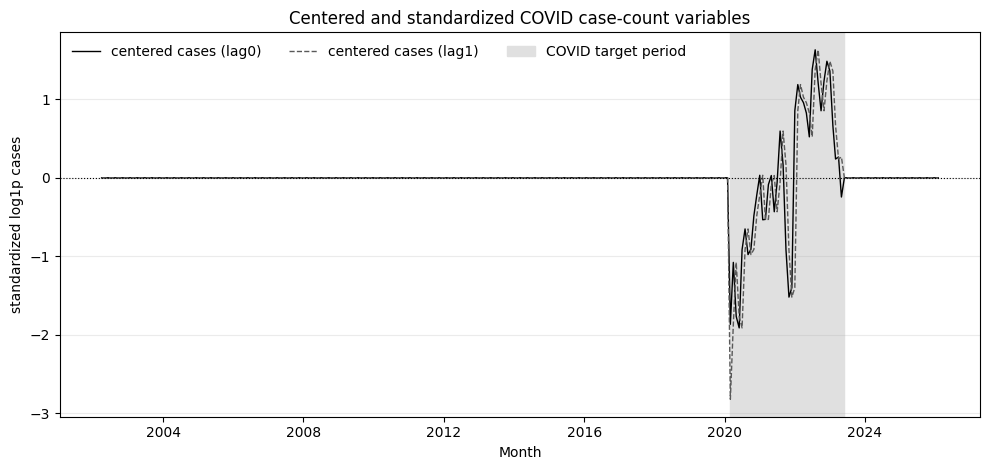

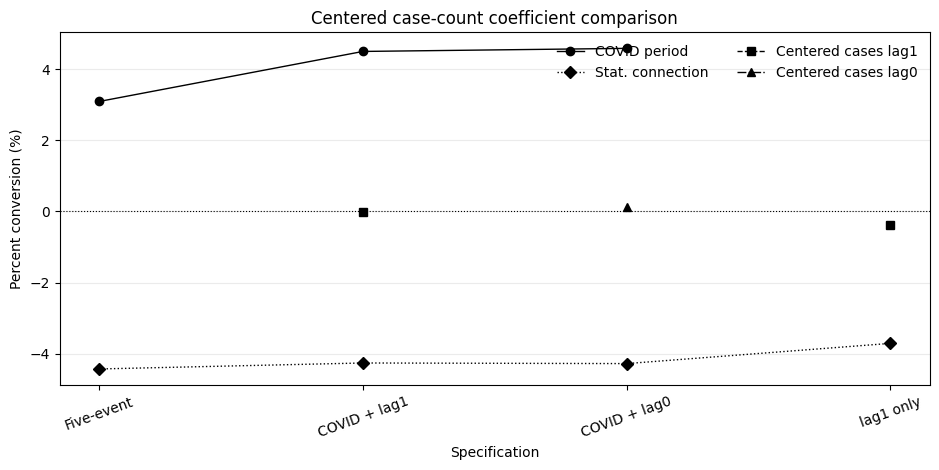

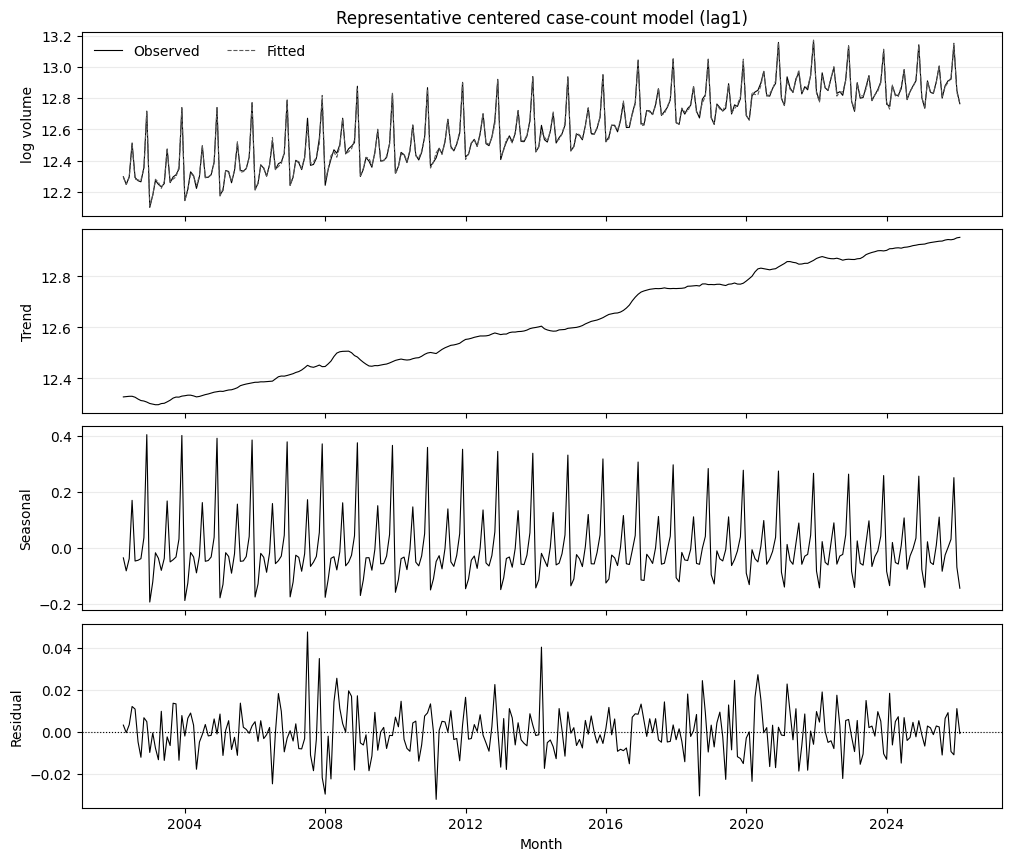

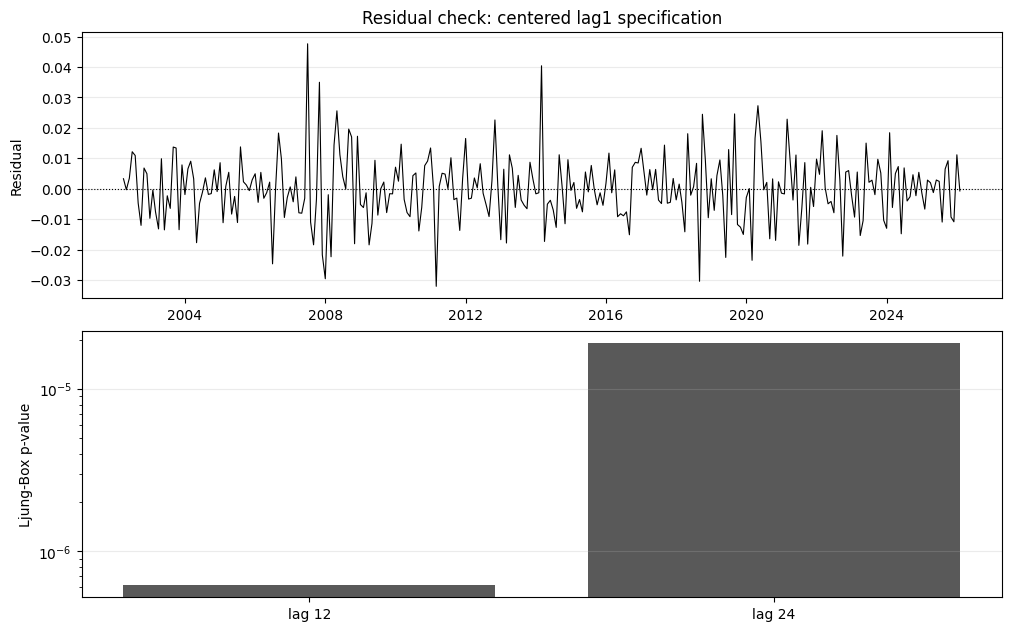

      lb_stat     lb_pvalue
12  52.006562  6.183124e-07
24  63.629757  1.929238e-05


In [8]:
# 中心化仕様の図表を保存する（既存の素朴仕様の図は上書きしない）。
# 図5：中心化・標準化感染者数系列
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot(
    centered_df.index,
    centered_df["centered_log1p_cases_lag0"],
    color="black",
    linewidth=1.0,
    label="centered cases (lag0)",
)
ax.plot(
    centered_df.index,
    centered_df["centered_log1p_cases_lag1"],
    color="0.35",
    linewidth=1.0,
    linestyle="--",
    label="centered cases (lag1)",
)
ax.axvspan(
    pd.Timestamp("2020-03-01"),
    pd.Timestamp("2023-05-31"),
    color="0.88",
    label="COVID target period",
)
ax.axhline(0, color="black", linestyle=":", linewidth=0.8)
ax.set_ylabel("standardized log1p cases")
ax.set_xlabel("Month")
ax.set_title("Centered and standardized COVID case-count variables")
ax.legend(frameon=False, ncol=3)
ax.grid(True, axis="y", alpha=0.25)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "centered_cases_exog_series.png", dpi=220, bbox_inches="tight")
plt.show()
plt.close(fig)

# 図6：中心化仕様の係数比較
centered_event_parameters = centered_coefficients[
    centered_coefficients["parameter"].str.endswith("_effect")
].copy()
centered_plot_params = [
    "covid_main_effect",
    "centered_log1p_cases_lag1_effect",
    "centered_log1p_cases_lag0_effect",
    "post_stat_change_effect",
]
centered_labels = {
    "covid_main_effect": "COVID period",
    "centered_log1p_cases_lag1_effect": "Centered cases lag1",
    "centered_log1p_cases_lag0_effect": "Centered cases lag0",
    "post_stat_change_effect": "Stat. connection",
}
centered_style_map = {
    "covid_main_effect": ("-", "o"),
    "centered_log1p_cases_lag1_effect": ("--", "s"),
    "centered_log1p_cases_lag0_effect": ("-.", "^"),
    "post_stat_change_effect": (":", "D"),
}
centered_plot = centered_event_parameters[
    centered_event_parameters["parameter"].isin(centered_plot_params)
]
centered_order = [
    "centered_current_five_event",
    "centered_covid_main_log1p_lag1",
    "centered_covid_main_log1p_lag0",
    "centered_log1p_lag1_only",
]
centered_order_labels = ["Five-event", "COVID + lag1", "COVID + lag0", "lag1 only"]
fig, ax = plt.subplots(figsize=(9.5, 4.8))
x = np.arange(len(centered_order))
for parameter, group in centered_plot.groupby("parameter", sort=False):
    values = group.set_index("model_id").reindex(centered_order)["percent_conversion"]
    linestyle, marker = centered_style_map[parameter]
    ax.plot(
        x,
        values,
        color="black",
        linestyle=linestyle,
        marker=marker,
        linewidth=1.0,
        label=centered_labels[parameter],
    )
ax.axhline(0, color="black", linewidth=0.8, linestyle=":")
ax.set_ylabel("Percent conversion (%)")
ax.set_xlabel("Specification")
ax.set_title("Centered case-count coefficient comparison")
ax.set_xticks(x, centered_order_labels)
ax.tick_params(axis="x", rotation=20)
ax.legend(frameon=False, ncol=2)
ax.grid(True, axis="y", alpha=0.25)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "centered_cases_exog_coefficients.png", dpi=220, bbox_inches="tight")
plt.show()
plt.close(fig)

# 図7：中心化lag1代表仕様の成分分解
centered_representative = centered_fit_objects["centered_covid_main_log1p_lag1"]
fig, axes = plt.subplots(
    4, 1, figsize=(10, 8.5), sharex=True, constrained_layout=True
)
axes[0].plot(
    centered_df.index,
    centered_representative["observed"],
    color="black",
    linewidth=0.8,
    label="Observed",
)
axes[0].plot(
    centered_df.index,
    centered_representative["fitted"],
    color="0.35",
    linestyle="--",
    linewidth=0.8,
    label="Fitted",
)
axes[0].set_ylabel("log volume")
axes[0].set_title("Representative centered case-count model (lag1)")
axes[0].legend(frameon=False, ncol=2)
axes[1].plot(centered_df.index, centered_representative["trend"], color="black", linewidth=0.8)
axes[1].set_ylabel("Trend")
axes[2].plot(centered_df.index, centered_representative["seasonal"], color="black", linewidth=0.8)
axes[2].set_ylabel("Seasonal")
axes[3].plot(centered_df.index, centered_representative["residual"], color="black", linewidth=0.8)
axes[3].axhline(0, color="black", linestyle=":", linewidth=0.8)
axes[3].set_ylabel("Residual")
axes[3].set_xlabel("Month")
for axis in axes:
    axis.grid(True, axis="y", alpha=0.25)
    axis.xaxis.set_major_locator(mdates.YearLocator(4))
    axis.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.savefig(FIGURES_DIR / "centered_cases_exog_components_lag1.png", dpi=220, bbox_inches="tight")
plt.show()
plt.close(fig)

# 図8：中心化lag1代表仕様の残差確認
centered_lb = acorr_ljungbox(
    centered_representative["residual"], lags=[12, 24], return_df=True
)
fig, axes = plt.subplots(2, 1, figsize=(10, 6.2), constrained_layout=True)
axes[0].plot(
    centered_df.index,
    centered_representative["residual"],
    color="black",
    linewidth=0.8,
)
axes[0].axhline(0, color="black", linestyle=":", linewidth=0.8)
axes[0].set_ylabel("Residual")
axes[0].set_title("Residual check: centered lag1 specification")
axes[0].grid(True, axis="y", alpha=0.25)
axes[1].bar(["lag 12", "lag 24"], centered_lb["lb_pvalue"].to_numpy(), color="0.35")
axes[1].set_yscale("log")
axes[1].set_ylabel("Ljung-Box p-value")
axes[1].grid(True, axis="y", alpha=0.25)
fig.savefig(FIGURES_DIR / "centered_cases_exog_residuals.png", dpi=220, bbox_inches="tight")
plt.show()
plt.close(fig)
print(centered_lb)


## 6. 中心化仕様の診断と解釈

中心化・標準化仕様では、感染者数係数が標準化された月次強弱に対する水準差として読める。素朴仕様と中心化仕様は変数のスケールとCOVID期ダミーとの役割分担が異なるため、係数の数値を直接比較せず、符号、適合度、残差診断、設計行列の相関・条件数を併せて確認する。

中心化仕様の主要結果は centered_model_comparison.csv、centered_coefficients.csv、centered_design_diagnostics.csv に保存した。全仕様で残差自己相関が残る場合、中心化・標準化によって診断上の問題が解消したとは解釈しない。また、感染者数係数はいずれも指定期間・指定ラグに対応するモデル上の関連であり、感染者数の因果効果ではない。

第一段階の素朴仕様は比較対象として保持し、中心化仕様を追加的な感度確認として扱う。
